In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

In [3]:
# criando o data frame a partir do arquivo csv
df = pd.read_csv('data.csv')


In [4]:
# limpando o data frame

df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
# entendendo os dados

# quantos registros existem de malignos e quantos de benignos?
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [6]:
# Teste com regressao linear simples

%pip install matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [7]:
#imports necessarios para o teste de regressao linear simples

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [8]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


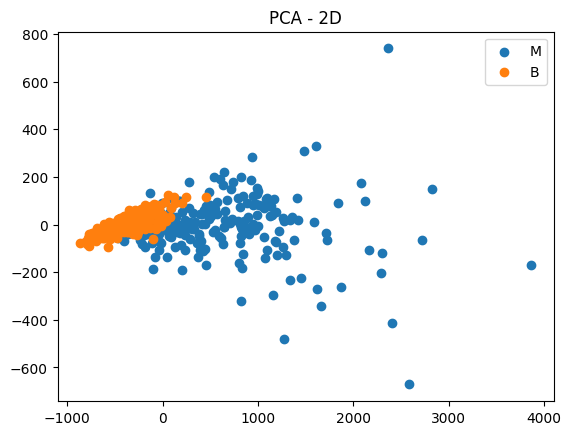

In [9]:
# transformando em duas dimensoes para visualizar melhor os dados

from sklearn.decomposition import PCA

# remove coluna que será usada para plotar os pontos no gráfico
X = df.drop(columns=['diagnosis'])

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# plot
plt.figure()
for label in df['diagnosis'].unique():
    plt.scatter(
        X_pca[df['diagnosis'] == label, 0],
        X_pca[df['diagnosis'] == label, 1],
        label=label
    )

plt.legend()
plt.title("PCA - 2D")
plt.show()

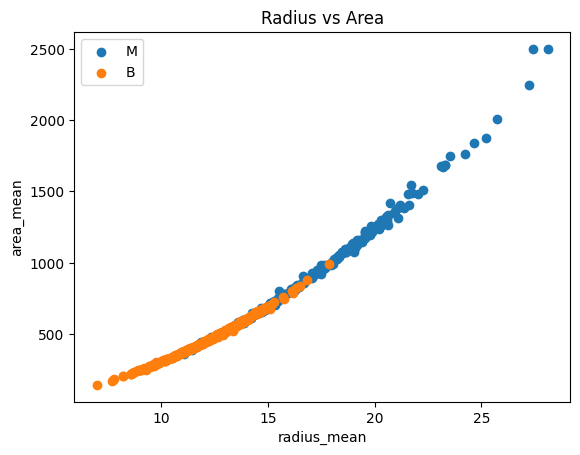

In [10]:
#dupla de dados pra plotar o gráfico de dispersão mais simples

plt.figure()

for label in df['diagnosis'].unique():
    subset = df[df['diagnosis'] == label]
    plt.scatter(
        subset['radius_mean'],
        subset['area_mean'],
        label=label
    )

plt.xlabel('radius_mean')
plt.ylabel('area_mean')
plt.legend()
plt.title('Radius vs Area')
plt.show()

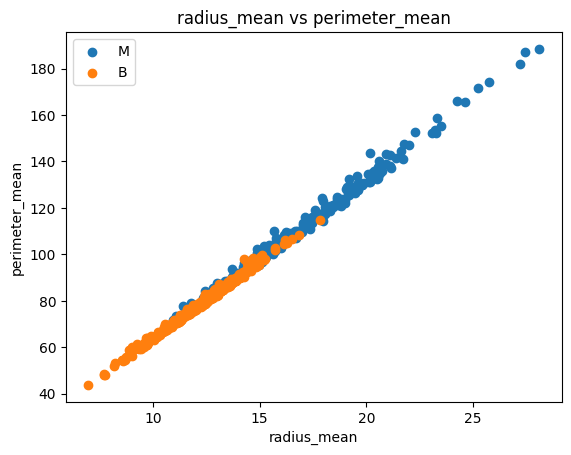

In [11]:

plt.figure()

for label in df['diagnosis'].unique():
    subset = df[df['diagnosis'] == label]
    plt.scatter(
        subset['radius_mean'],
        subset['perimeter_mean'],
        label=label
    )

plt.xlabel('radius_mean')
plt.ylabel('perimeter_mean')
plt.legend()
plt.title('radius_mean vs perimeter_mean')
plt.show()

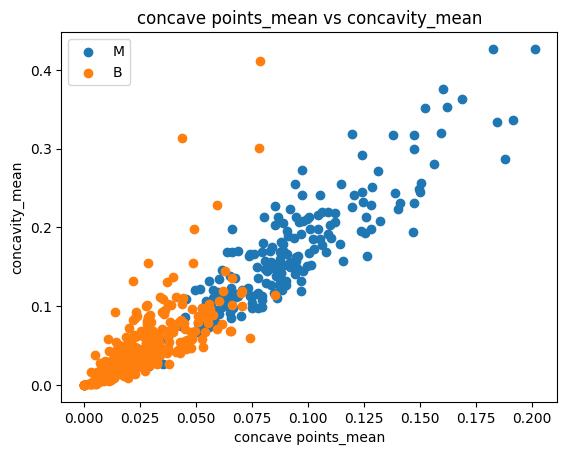

In [12]:
plt.figure()

for label in df['diagnosis'].unique():
    subset = df[df['diagnosis'] == label]
    plt.scatter(
        subset['concave points_mean'],
        subset['concavity_mean'],
        label=label
    )

plt.xlabel('concave points_mean')
plt.ylabel('concavity_mean')
plt.legend()
plt.title('concave points_mean vs concavity_mean')
plt.show()

In [13]:
# treinando o modelo de regressão linear simples

# criando X e Y
X = df.drop('diagnosis', axis=1)
y = df['diagnosis'].map({'M': 1, 'B': 0}) # alterando para binário para regressao linear

# dividindo em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% testess
    random_state=100,    # reprodutibilidade
    stratify=y          # mantém proporção M/B
)

# treinando o modelo
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
# printando os resultados do treinamento do modelo
model_score = model.score(X_test, y_test)
print(f"Score do modelo: {model_score*100:.2f}%")

Score do modelo: 74.21%


In [15]:
# Regressao linear multipla
import numpy as np
np.random.seed(126)

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('axes', labelsize=14)    # fontsize of the x and y labels
mpl.rc('xtick', labelsize=12)   # fontsize of the tick labels
mpl.rc('ytick', labelsize=12)   # fontsize of the tick labels

In [16]:
#conhecendo melhor os dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

In [17]:
df.shape

(569, 31)

In [18]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


array([[<Axes: title={'center': 'radius_mean'}>,
        <Axes: title={'center': 'texture_mean'}>,
        <Axes: title={'center': 'perimeter_mean'}>,
        <Axes: title={'center': 'area_mean'}>,
        <Axes: title={'center': 'smoothness_mean'}>],
       [<Axes: title={'center': 'compactness_mean'}>,
        <Axes: title={'center': 'concavity_mean'}>,
        <Axes: title={'center': 'concave points_mean'}>,
        <Axes: title={'center': 'symmetry_mean'}>,
        <Axes: title={'center': 'fractal_dimension_mean'}>],
       [<Axes: title={'center': 'radius_se'}>,
        <Axes: title={'center': 'texture_se'}>,
        <Axes: title={'center': 'perimeter_se'}>,
        <Axes: title={'center': 'area_se'}>,
        <Axes: title={'center': 'smoothness_se'}>],
       [<Axes: title={'center': 'compactness_se'}>,
        <Axes: title={'center': 'concavity_se'}>,
        <Axes: title={'center': 'concave points_se'}>,
        <Axes: title={'center': 'symmetry_se'}>,
        <Axes: title={'ce

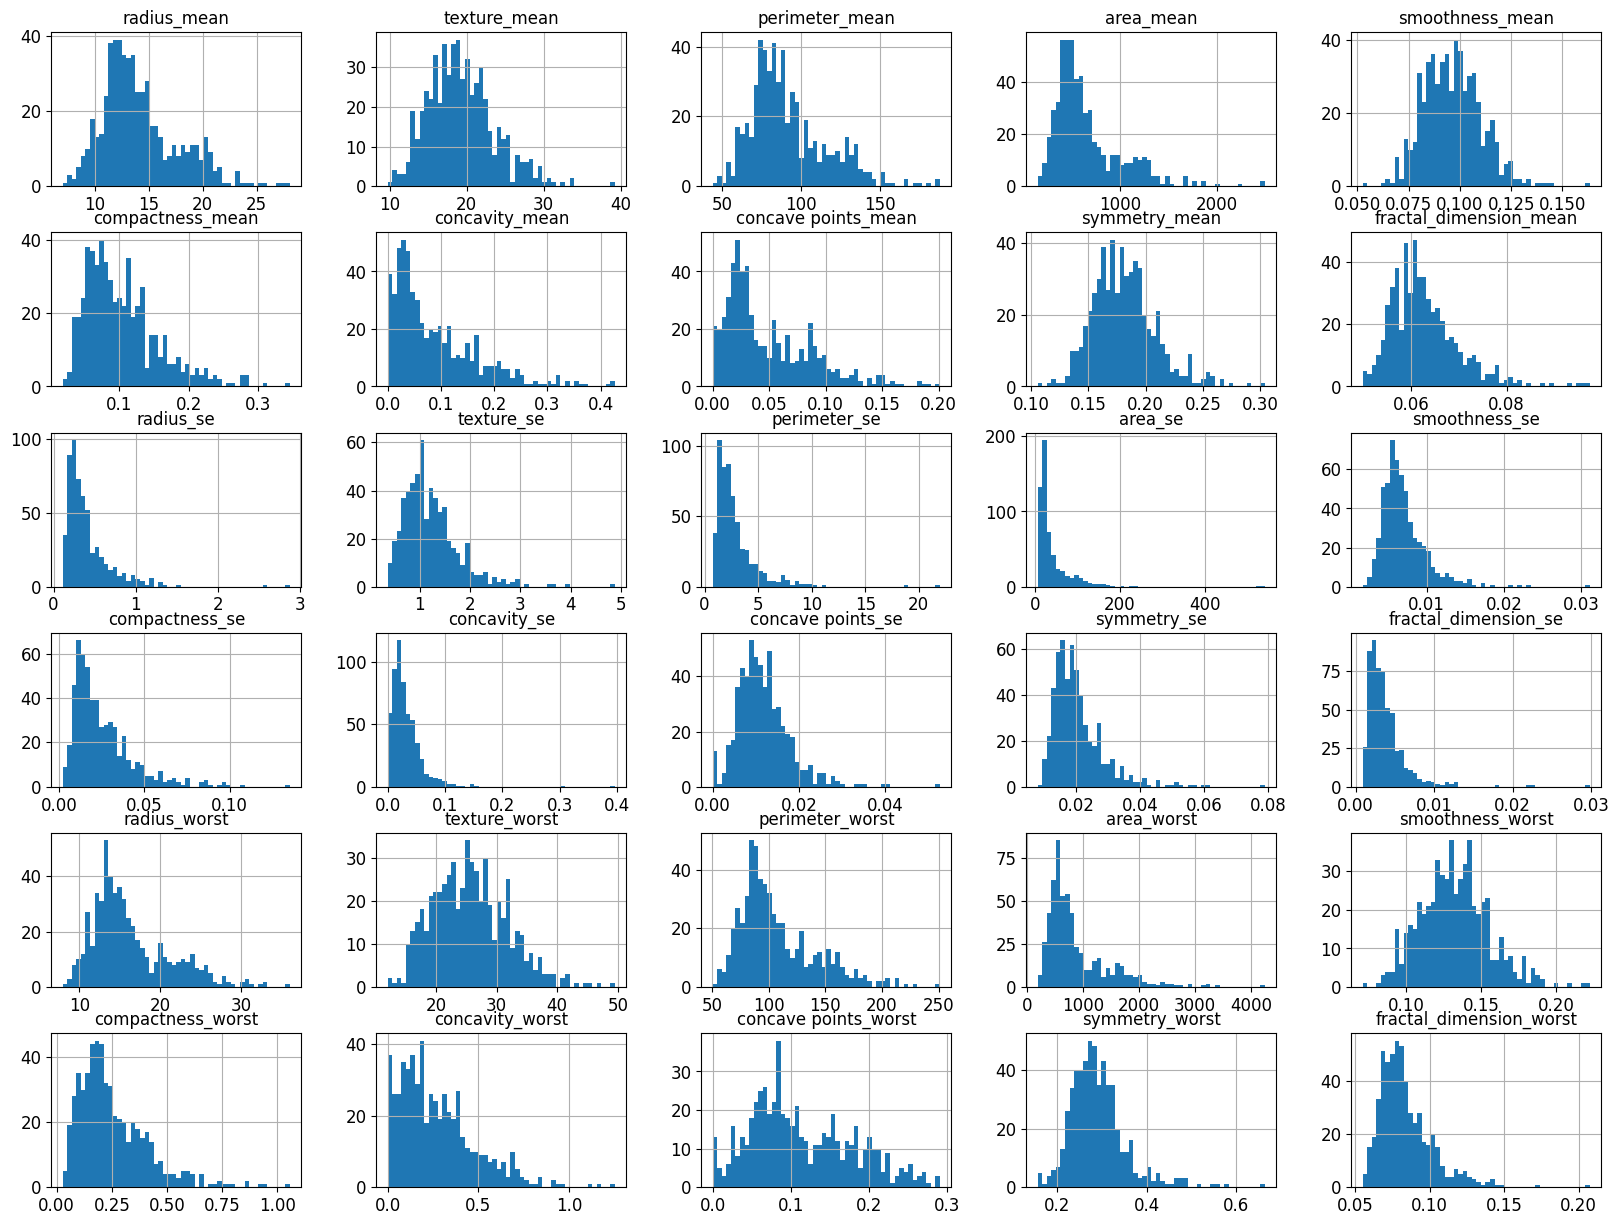

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt

df.hist(bins=50, figsize=(20, 15))

In [20]:
# separando dados de treino e teste
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df,
    test_size=0.12,
    random_state=6546,
    stratify=df['diagnosis']  # ESSENCIAL
)

print(len(df_train), "treinamento +", len(df_test), "teste")

500 treinamento + 69 teste


In [21]:
# 1. Separar X e y

X_train = df_train.drop('diagnosis', axis=1)
y_train = df_train['diagnosis']

X_test = df_test.drop('diagnosis', axis=1)
y_test = df_test['diagnosis']

In [22]:
# 2. Converter M/B → 0/1
y_train = y_train.map({'M': 1, 'B': 0})
y_test = y_test.map({'M': 1, 'B': 0})

In [23]:
# Normalização. Essas features têm escalas MUITO diferentes
# pelo oq eu entendi essa etapa de scaler serve pra 'achatar' os dados, pois na hora de calcular adistância entre os pontos, se uma feature tiver um valor muito maior que as outras, ela vai dominar a distância e o modelo pode não aprender bem

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
#Modelo (regressão logística)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
# Avaliacao 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("=" * 50)
print("📊 RESULTADOS")
print("=" * 50)

print("\n🎯 Accuracy:")
print(accuracy_score(y_test, y_pred)*100, "%")

print("\n📉 Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred))

print("=" * 50)

📊 RESULTADOS

🎯 Accuracy:
98.55072463768117 %

📉 Matriz de Confusão:
[[43  0]
 [ 1 25]]

📄 Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        43
           1       1.00      0.96      0.98        26

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



In [26]:
# alterando o threshold para 0.3 com o objetivo de diminuir falsos negativos com o tradeoff de aumentar falsos positivos

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

In [28]:
y_prob = model.predict_proba(X_test)[:, 1]

def avaliar_threshold(threshold):
    y_pred_custom = (y_prob >= threshold).astype(int)
    
    print("=" * 50)
    print(f"📊 THRESHOLD = {threshold}")
    print("=" * 50)
    
    print("\n📉 Matriz de Confusão:")
    print(confusion_matrix(y_test, y_pred_custom))
    
    print("\n📄 Classification Report:")
    print(classification_report(y_test, y_pred_custom))


In [29]:
for t in [0.5, 0.4, 0.3, 0.2, 0.15, 0.1]:
    avaliar_threshold(t)

📊 THRESHOLD = 0.5

📉 Matriz de Confusão:
[[43  0]
 [ 1 25]]

📄 Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        43
           1       1.00      0.96      0.98        26

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69

📊 THRESHOLD = 0.4

📉 Matriz de Confusão:
[[42  1]
 [ 1 25]]

📄 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.96      0.96      0.96        26

    accuracy                           0.97        69
   macro avg       0.97      0.97      0.97        69
weighted avg       0.97      0.97      0.97        69

📊 THRESHOLD = 0.3

📉 Matriz de Confusão:
[[41  2]
 [ 1 25]]

📄 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95

In [30]:
# Com esse teste me parece que é um ponto específico muito fora da curva. 
# como se tivesse tudo pra dizer que é B mas na verdade é M
# vou agora investigar esse ponto específico pra ver o que tem de diferente nele

In [31]:
# pegar predição com threshold atual (ex: 0.5 ou o que quiser)
threshold = 0.5
y_pred_custom = (y_prob >= threshold).astype(int)

# identificar falsos negativos (era 1, mas previu 0)
false_negatives_idx = (y_test == 1) & (y_pred_custom == 0)

# ver quantos são
print("Quantidade de falsos negativos:", false_negatives_idx.sum())

Quantidade de falsos negativos: 1


In [34]:
# garantir tudo como array (sem índice)
y_test_array = y_test.to_numpy()

# recalcular o mask corretamente
false_negatives_idx = (y_test_array == 1) & (y_pred_custom == 0)

# agora funciona
fn_case = X_test[false_negatives_idx]

print(fn_case)

[[ 0.96532598  1.41556392  0.96122144  0.87176498  0.32435658  0.21249544
   1.03828278  0.46595642 -1.88311517 -0.57921524  0.49967218  0.87944931
   0.51381672  0.48400509  8.50038569  3.42516841  3.69723694  4.70915583
   0.20309853  3.26315813  0.39167257  0.35614688  0.41258384  0.27074625
  -0.34773459 -0.47343456  0.03980366 -0.06336288 -2.11512149 -0.87259718]]


In [35]:
# probabilidade do modelo para esse caso especifico 

print("Probabilidade do modelo pra esse caso:")
print(y_prob[false_negatives_idx])

Probabilidade do modelo pra esse caso:
[0.02242224]


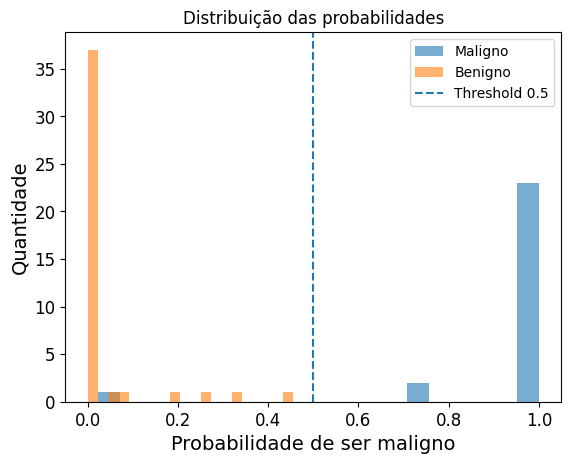

In [36]:
import matplotlib.pyplot as plt

# separar probabilidades por classe real
prob_maligno = y_prob[y_test == 1]
prob_benigno = y_prob[y_test == 0]

plt.hist(prob_maligno, bins=20, alpha=0.6, label='Maligno')
plt.hist(prob_benigno, bins=20, alpha=0.6, label='Benigno')

plt.axvline(x=0.5, linestyle='--', label='Threshold 0.5')

plt.legend()
plt.title("Distribuição das probabilidades")
plt.xlabel("Probabilidade de ser maligno")
plt.ylabel("Quantidade")

plt.show()

⚠️ Conclusão importante
❌ Isso NÃO é problema de threshold
✅ Isso é problema de representação / separação do modelo

Tentei reduzir o threshold, mas mesmo assim ele manteve o erro, e agora quero entender POR QUE o modelo ta enganado aqui.

In [ ]:
#vou comparar esse ponto com a media de M e B para entender pq o modelo tem tanta ctz de que ele é B quando na verdade é M

# médias por classe
mean_maligno = df[df['diagnosis'] == 'M'].mean(numeric_only=True)
mean_benigno = df[df['diagnosis'] == 'B'].mean(numeric_only=True)

# edge case
ponto = df_test[false_negatives_idx].iloc[0]

# comparar com algumas features
for col in ['radius_mean', 'texture_mean', 'area_mean', 'concavity_mean']:
    print(f"\n🔹 {col}")
    print(f"ponto:     {ponto[col]:.4f}")
    print(f"maligno:   {mean_maligno[col]:.4f}")
    print(f"benigno:   {mean_benigno[col]:.4f}")

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [ ]:
# Modelo nao linear para desencargo de consiencia floresta randomica 

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Probabilidade (RandomForest):")
print(y_prob_rf[false_negatives_idx])

In [ ]:
# previsão binária com threshold padrão
y_pred_rf = (y_prob_rf >= 0.5).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print("=" * 50)
print("🌳 RANDOM FOREST RESULTADOS")
print("=" * 50)

print("\n📉 Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf))

print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred_rf))

In [ ]:
import matplotlib.pyplot as plt

# Logistic Regression
prob_lr = y_prob

# Random Forest
prob_rf = y_prob_rf

plt.hist(prob_lr[y_test == 1], alpha=0.5, label='LR - Maligno')
plt.hist(prob_lr[y_test == 0], alpha=0.5, label='LR - Benigno')

plt.title("Distribuição - Logistic Regression")
plt.legend()
plt.show()


plt.hist(prob_rf[y_test == 1], alpha=0.5, label='RF - Maligno')
plt.hist(prob_rf[y_test == 0], alpha=0.5, label='RF - Benigno')

plt.title("Distribuição - Random Forest")
plt.legend()
plt.show()

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(rf.estimators_[0], filled=True, max_depth=3)
plt.show()

In [ ]:
df["diagnosis"].value_counts() / len(df)